In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import (confusion_matrix,classification_report,precision_score,
                             recall_score,f1_score,roc_curve,roc_auc_score
)
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("cleaned_data.csv")
print(df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt season_label  
0   985       Spring  
1   801       Spring  
2  1349       Spr

In [36]:
target = "cnt"
X = df.drop(columns=[target, "casual", "registered", "dteday", "instant", "season"])
y_reg = df[target]
y_clf = (y_reg > y_reg.median()).astype(int)

In [37]:
nominal_cols = ["season_label", "mnth", "weekday"]
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)


In [38]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_reg_train)
pred_lr = lr.predict(X_test_scaled)
print("Linear Regression MSE:", mean_squared_error(y_reg_test, pred_lr))
print("Linear Regression R2:", r2_score(y_reg_test, pred_lr))

Linear Regression MSE: 683198.4417487497
Linear Regression R2: 0.8296213223779949


In [41]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_reg_train)
pred_ridge = ridge.predict(X_test_scaled)
print("Ridge MSE:", mean_squared_error(y_reg_test, pred_ridge))
print("Ridge R2:", r2_score(y_reg_test, pred_ridge))

Ridge MSE: 682394.5434737914
Ridge R2: 0.8298218016482335


In [42]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})
coef_df["Importance"] = coef_df["Coefficient"].abs()
top_features = coef_df.sort_values(by="Importance", ascending=False).head(3)
print(top_features)

                Feature  Coefficient  Importance
0                    yr   999.748584  999.748584
4                  temp   629.995845  629.995845
10  season_label_Winter   381.630482  381.630482


In [43]:
print(y_clf_train.value_counts())
print(y_clf_train.value_counts(normalize=True) * 100)

cnt
1    299
0    285
Name: count, dtype: int64
cnt
1    51.19863
0    48.80137
Name: proportion, dtype: float64


In [44]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_scaled, y_clf_train)
print("Using class_weight='balanced'")
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

Using class_weight='balanced'


In [45]:
# Logistic Regression with stronger regularization
model2 = LogisticRegression(C=0.01, max_iter=1000, class_weight="balanced")
model2.fit(X_train_scaled, y_clf_train)
# Predicted probabilities
prob2 = model2.predict_proba(X_test_scaled)[:, 1]
# Compare AUC scores
auc1 = roc_auc_score(y_clf_test, y_prob)
auc2 = roc_auc_score(y_clf_test, prob2)
print("AUC (C = 1.0):", auc1)
print("AUC (C = 0.01):", auc2)

AUC (C = 1.0): 0.9607182940516275
AUC (C = 0.01): 0.9431350542461654


In [46]:
print(confusion_matrix(y_clf_test, y_pred))
print(classification_report(y_clf_test, y_pred))

[[71 10]
 [ 9 57]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88        81
           1       0.85      0.86      0.86        66

    accuracy                           0.87       147
   macro avg       0.87      0.87      0.87       147
weighted avg       0.87      0.87      0.87       147



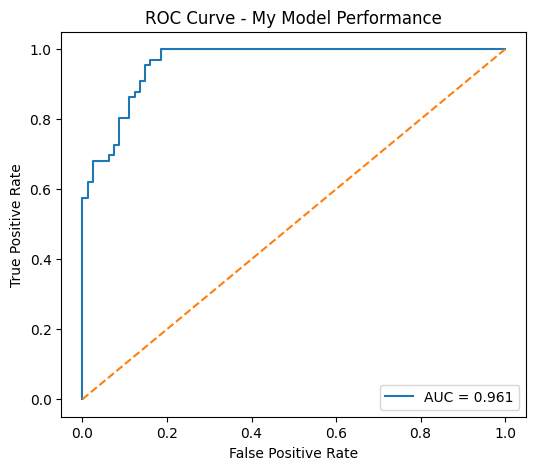

My Model AUC Score: 0.9607182940516275


In [47]:
fal_pos_rate, tr_pos_rate, thres_list = roc_curve(y_clf_test, y_prob)
auc_score_value = roc_auc_score(y_clf_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fal_pos_rate, tr_pos_rate, label=f"AUC = {auc_score_value:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - My Model Performance")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")
plt.show()
print("My Model AUC Score:", auc_score_value)


In [48]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
rows = []
for t in thresholds:
    pred = (y_prob >= t).astype(int)
    rows.append([
        t,
        precision_score(y_clf_test, pred),
        recall_score(y_clf_test, pred),
        f1_score(y_clf_test, pred)
    ])
threshold_df = pd.DataFrame(rows, columns=["Threshold","Precision","Recall","F1"])
print(threshold_df)

   Threshold  Precision    Recall        F1
0        0.3   0.810127  0.969697  0.882759
1        0.4   0.835616  0.924242  0.877698
2        0.5   0.850746  0.863636  0.857143
3        0.6   0.857143  0.818182  0.837209
4        0.7   0.883333  0.803030  0.841270


In [49]:
best = threshold_df.loc[threshold_df["F1"].idxmax()]
print("\nBest Threshold based on F1:")
print(best)


Best Threshold based on F1:
Threshold    0.300000
Precision    0.810127
Recall       0.969697
F1           0.882759
Name: 0, dtype: float64


In [50]:
y_pred_c1 = model.predict(X_test_scaled)
y_prob_c1 = model.predict_proba(X_test_scaled)[:, 1]
y_pred_c2 = model2.predict(X_test_scaled)
y_prob_c2 = model2.predict_proba(X_test_scaled)[:, 1]

compare = pd.DataFrame({
    "Model": ["C=1.0", "C=0.01"],
    "Precision": [
        precision_score(y_clf_test, y_pred_c1),
        precision_score(y_clf_test, y_pred_c2)
    ],
    "Recall": [
        recall_score(y_clf_test, y_pred_c1),
        recall_score(y_clf_test, y_pred_c2)
    ],
    "AUC": [
        roc_auc_score(y_clf_test, y_prob_c1),
        roc_auc_score(y_clf_test, y_prob_c2)
    ]
})

print(compare)

    Model  Precision    Recall       AUC
0   C=1.0   0.850746  0.863636  0.960718
1  C=0.01   0.849315  0.939394  0.943135


In [51]:
diffs = []
for i in range(500):
    idx = np.random.choice(len(y_clf_test), len(y_clf_test), replace=True)
    auc1 = roc_auc_score(y_clf_test.iloc[idx], y_prob[idx])
    auc2 = roc_auc_score(y_clf_test.iloc[idx], prob2[idx])

    diffs.append(auc1 - auc2)

print("Mean difference:", np.mean(diffs))
print("95% CI:", np.percentile(diffs, [2.5, 97.5]))

Mean difference: 0.017155009660783656
95% CI: [0.00046093 0.03759343]


In [52]:
lower, upper = np.percentile(diffs, [2.5, 97.5])

if lower > 0 or upper < 0:
    print("\nThe 95% confidence interval excludes zero.")
    print("This suggests the performance difference between the C=1.0 and C=0.01 models is statistically reliable.")
else:
    print("\nThe 95% confidence interval includes zero.")
    print("This suggests the observed difference may not be statistically reliable.")


The 95% confidence interval excludes zero.
This suggests the performance difference between the C=1.0 and C=0.01 models is statistically reliable.
